In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.sql.types import IntegerType, FloatType

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StandardScaler
from pyspark.ml.feature import PCA
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.sql.functions import col, when
import matplotlib.pyplot as plt

In [2]:
# =========================================================
# SPARK SESSION
# =========================================================

spark = SparkSession.builder \
    .appName("SpotifyClustering") \
    .config("spark.sql.warehouse.dir", "/user/hive/warehouse") \
    .enableHiveSupport() \
    .getOrCreate()

print("Spark Master:", spark.sparkContext.master)


Spark Master: local[*]


26/05/11 12:07:59 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [3]:
# =========================================================
# LOAD DATA FROM HIVE
# =========================================================

df = spark.sql("""
SELECT *
FROM spotify_db.spotify_tracks
""")


df = df.filter(
    col("popularity") != "popularity"
)


26/05/11 12:08:00 WARN HiveConf: HiveConf of name hive.stats.jdbc.timeout does not exist
26/05/11 12:08:00 WARN HiveConf: HiveConf of name hive.stats.retries.wait does not exist
26/05/11 12:08:04 WARN ObjectStore: Failed to get database global_temp, returning NoSuchObjectException


In [4]:
# =========================================================
# ALTERNATIVE:
# LOAD DATA FROM HDFS (NON-HIVE)
# =========================================================

# Uncomment jika ingin load langsung dari HDFS
# dan tidak menggunakan Hive

# df = spark.read \
#     .option("header", True) \
#     .option("inferSchema", True) \
#     .csv("hdfs:///user/hadoop/data/dataset.csv")



In [5]:
# =========================================================
# PREPROCESSING
# =========================================================

# -----------------------------------------
# Convert explicit TRUE/FALSE -> 1/0
# -----------------------------------------

df = df.withColumn(
    "explicit_numeric",
    when(col("explicit") == True, 1).otherwise(0)
)


In [6]:
# -----------------------------------------
# Pilih feature untuk clustering
# -----------------------------------------

feature_columns = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "loudness"
]

In [7]:
# =========================================================
# CREATE CLEAN DATAFRAME
# =========================================================

df_clean = df.select(
    *feature_columns,
    "track_genre"
)

In [8]:
# =========================================================
# CHECK NULL
# =========================================================

from pyspark.sql.functions import col, sum, when

df_clean.select([
    sum(
        when(col(c).isNull(), 1).otherwise(0)
    ).alias(c)
    for c in feature_columns
]).show()

26/05/11 12:08:09 WARN SessionState: METASTORE_FILTER_HOOK will be ignored, since hive.security.authorization.manager is set to instance of HiveAuthorizerFactory.
                                                                                

+------------+------+-----------+------------+----------------+--------+-------+-----+--------+
|danceability|energy|speechiness|acousticness|instrumentalness|liveness|valence|tempo|loudness|
+------------+------+-----------+------------+----------------+--------+-------+-----+--------+
|           0|     0|          0|           0|               0|       0|      0|    0|       0|
+------------+------+-----------+------------+----------------+--------+-------+-----+--------+



In [9]:
# =========================================================
# CAST STRING -> DOUBLE
# =========================================================

for column_name in feature_columns:
    df_clean = df_clean.withColumn(
        column_name,
        col(column_name).cast("double")
    )


In [10]:
# =========================================================
# DROP NULL
# =========================================================

df_clean = df_clean.dropna(subset=feature_columns)

# Optional debug
df_clean.printSchema()

root
 |-- danceability: double (nullable = true)
 |-- energy: double (nullable = true)
 |-- speechiness: double (nullable = true)
 |-- acousticness: double (nullable = true)
 |-- instrumentalness: double (nullable = true)
 |-- liveness: double (nullable = true)
 |-- valence: double (nullable = true)
 |-- tempo: double (nullable = true)
 |-- loudness: double (nullable = true)
 |-- track_genre: string (nullable = true)



In [11]:
# =========================================================
# LIMIT DATA UNTUK TESTING
# =========================================================

# df_clean = df_clean.sample(
#     fraction=0.1,
#     seed=42
# )

print(df_clean.count())

[Stage 3:>                                                          (0 + 1) / 1]

114000


In [12]:
# =========================================================
# VECTOR ASSEMBLER
# =========================================================

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features_raw",
    handleInvalid="skip"
)

df_vector = assembler.transform(df_clean)

In [13]:
# =========================================================
# STANDARD SCALING
# =========================================================

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(df_vector)

df_scaled = scaler_model.transform(df_vector)

In [14]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

print("Mencari nilai K optimal (Hyperparameter Tuning):")
silhouette_scores = []
k_values = range(3, 11) 

for k in k_values:
    # Buat model K-Means
    kmeans_temp = KMeans(k=k, seed=42, featuresCol="features", predictionCol="cluster")
    model_temp = kmeans_temp.fit(df_scaled)
    predictions_temp = model_temp.transform(df_scaled)
    
    
    evaluator = ClusteringEvaluator(
        featuresCol="features", 
        predictionCol="cluster",
        metricName="silhouette"
    )
    
    score = evaluator.evaluate(predictions_temp)
    silhouette_scores.append(score)
    
    print(f"K = {k} | Silhouette Score = {score}")

Mencari nilai K optimal (Hyperparameter Tuning):


26/05/11 12:08:29 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
                                                                                

K = 3 | Silhouette Score = 0.2652667786612602


K = 4 | Silhouette Score = 0.27281678859384806


K = 5 | Silhouette Score = 0.2866101603351568


...

K = 7 | Silhouette Score = 0.3250974308465008


K = 8 | Silhouette Score = 0.29064471529679653


K = 9 | Silhouette Score = 0.2267622812866085


[Stage 478:>                                                        (0 + 1) / 1]

K = 10 | Silhouette Score = 0.2757445936379693


In [15]:
# =========================================================
# KMEANS
# =========================================================

k = 7

kmeans = KMeans(
    k=k,
    seed=42,
    featuresCol="features",
    predictionCol="cluster"
)

model = kmeans.fit(df_scaled)

df_clustered = model.transform(df_scaled)


In [16]:
# =========================================================
# EVALUATION
# =========================================================

evaluator = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="cluster",
    metricName="silhouette"
)

silhouette = evaluator.evaluate(df_clustered)

print(f"Silhouette Score: {silhouette}")

[Stage 537:>                                                        (0 + 1) / 1]

Silhouette Score: 0.3250974308465008


In [17]:
# =========================================================
# SHOW SAMPLE RESULT
# =========================================================

df_clustered.select(
    "track_genre",
    "cluster"
).show(20, truncate=False)


+-----------+-------+
|track_genre|cluster|
+-----------+-------+
|acoustic   |4      |
|acoustic   |1      |
|acoustic   |1      |
|acoustic   |1      |
|acoustic   |1      |
|acoustic   |4      |
|acoustic   |1      |
|acoustic   |1      |
|acoustic   |4      |
|acoustic   |1      |
|acoustic   |1      |
|acoustic   |1      |
|acoustic   |1      |
|acoustic   |1      |
|acoustic   |4      |
|acoustic   |1      |
|acoustic   |1      |
|acoustic   |1      |
|acoustic   |4      |
|acoustic   |1      |
+-----------+-------+
only showing top 20 rows



In [18]:
# =========================================================
# CLUSTER DISTRIBUTION
# =========================================================

df_clustered.groupBy("cluster").count().show()

[Stage 541:>                                                        (0 + 1) / 1]

+-------+-----+
|cluster|count|
+-------+-----+
|      1|23048|
|      6| 1197|
|      3| 7432|
|      5| 7688|
|      4|36918|
|      2|11765|
|      0|25952|
+-------+-----+



In [19]:
# =========================================================
# CLUSTER PROFILE
# =========================================================

cluster_profile = df_clustered.groupBy("cluster").avg(
    *feature_columns
)

cluster_profile.show(truncate=False)

[Stage 544:>                                                        (0 + 1) / 1]

+-------+-------------------+-------------------+--------------------+-------------------+---------------------+-------------------+-------------------+------------------+-------------------+
|cluster|avg(danceability)  |avg(energy)        |avg(speechiness)    |avg(acousticness)  |avg(instrumentalness)|avg(liveness)      |avg(valence)       |avg(tempo)        |avg(loudness)      |
+-------+-------------------+-------------------+--------------------+-------------------+---------------------+-------------------+-------------------+------------------+-------------------+
|1      |0.530554750954529  |0.37722456967198864|0.05258995574453315 |0.6764375509002932 |0.028748236218760773 |0.15768333477959035|0.392408990367925  |113.14194580874799|-10.624786402290841|
|6      |0.57885797827903   |0.6591149540517973 |0.8058354218880521  |0.7148997020885551 |0.010916938045112788 |0.6152702589807839 |0.4475411862990816 |102.9357928153718 |-11.022883040935678|
|3      |0.3472611141011825 |0.169611358

In [20]:
# =========================================================
# TOP 10 GENRE PER CLUSTER
# =========================================================

from pyspark.sql.window import Window
from pyspark.sql.functions import col, row_number

# Hitung jumlah genre per cluster
genre_count = df_clustered.groupBy(
    "cluster",
    "track_genre"
).count()

# Window untuk ranking per cluster
window_spec = Window.partitionBy("cluster").orderBy(col("count").desc())

# Ambil top 10 genre tiap cluster
top_10_genre = genre_count.withColumn(
    "rank",
    row_number().over(window_spec)
).filter(
    col("rank") <= 10
).orderBy(
    "cluster",
    "rank"
)

# Tampilkan hasil
top_10_genre.show(1000, truncate=False)

[Stage 547:>                                                        (0 + 1) / 1]

+-------+-----------------+-----+----+
|cluster|track_genre      |count|rank|
+-------+-----------------+-----+----+
|0      |metalcore        |828  |1   |
|0      |heavy-metal      |696  |2   |
|0      |hardstyle        |693  |3   |
|0      |dubstep          |673  |4   |
|0      |metal            |667  |5   |
|0      |grunge           |664  |6   |
|0      |death-metal      |641  |7   |
|0      |happy            |535  |8   |
|0      |hardcore         |525  |9   |
|0      |j-idol           |519  |10  |
|1      |tango            |783  |1   |
|1      |honky-tonk       |773  |2   |
|1      |romance          |768  |3   |
|1      |jazz             |729  |4   |
|1      |cantopop         |691  |5   |
|1      |songwriter       |636  |6   |
|1      |singer-songwriter|636  |7   |
|1      |mandopop         |631  |8   |
|1      |acoustic         |629  |9   |
|1      |show-tunes       |615  |10  |
|2      |minimal-techno   |866  |1   |
|2      |detroit-techno   |770  |2   |
|2      |techno          

In [21]:
# =========================================================
# VISUALIZATION
# =========================================================

from pyspark.ml.feature import PCA
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------------------
# PCA 2D
# -----------------------------------------

pca = PCA(
    k=2,
    inputCol="features",
    outputCol="pca_features"
)

pca_model = pca.fit(df_scaled)

df_pca = pca_model.transform(df_clustered)


26/05/11 12:10:05 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


In [22]:
# -----------------------------------------
# Extract PCA values
# -----------------------------------------

df_plot = df_pca.select(
    "cluster",
    "pca_features"
).toPandas()

df_plot["pca_x"] = df_plot["pca_features"].apply(lambda x: float(x[0]))
df_plot["pca_y"] = df_plot["pca_features"].apply(lambda x: float(x[1]))

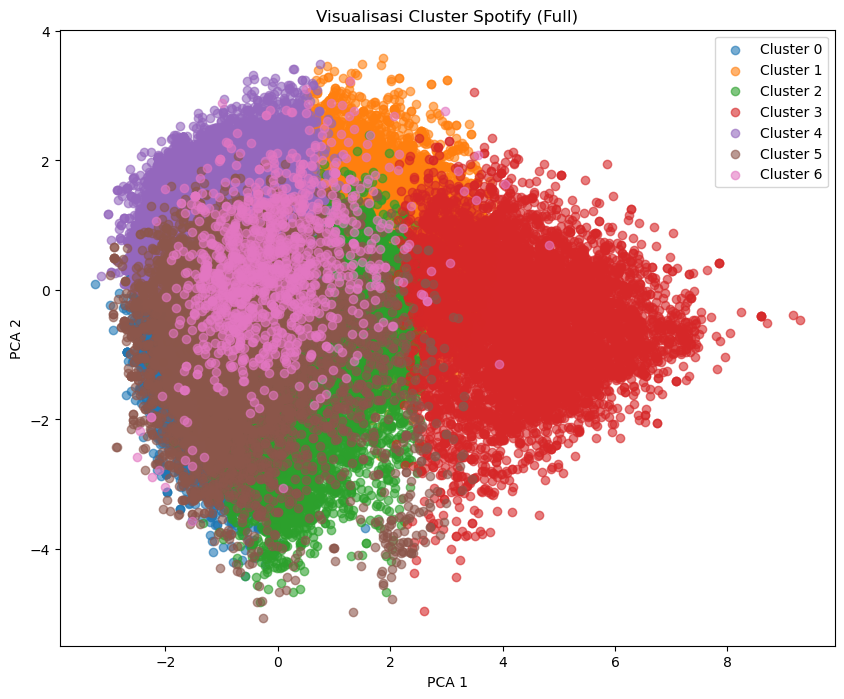

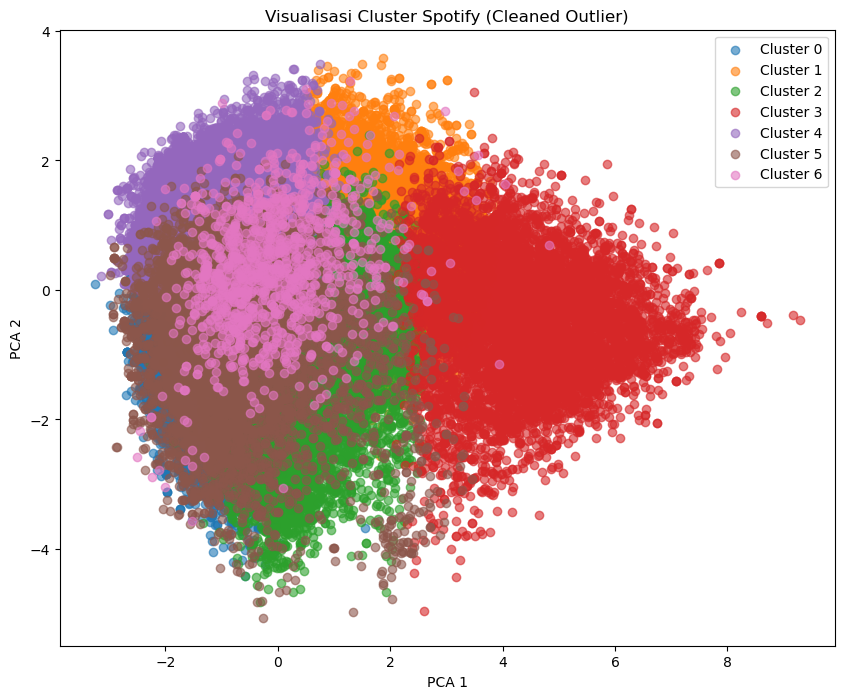

In [23]:
# =========================================================
# PLOT 1 : FULL DATA
# =========================================================

plt.figure(figsize=(10, 8))

for cluster_id in sorted(df_plot["cluster"].unique()):
    cluster_data = df_plot[df_plot["cluster"] == cluster_id]

    plt.scatter(
        cluster_data["pca_x"],
        cluster_data["pca_y"],
        label=f"Cluster {cluster_id}",
        alpha=0.6
    )

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Visualisasi Cluster Spotify (Full)")
plt.legend()

plt.show()

# =========================================================
# PLOT 2 : CLEAN / REMOVE EXTREME OUTLIER
# =========================================================

# threshold bisa diubah sesuai kebutuhan
df_plot_clean = df_plot[
    (df_plot["pca_x"] > -20) &
    (df_plot["pca_x"] < 20) &
    (df_plot["pca_y"] > -20) &
    (df_plot["pca_y"] < 20)
]

plt.figure(figsize=(10, 8))

for cluster_id in sorted(df_plot_clean["cluster"].unique()):
    cluster_data = df_plot_clean[df_plot_clean["cluster"] == cluster_id]

    plt.scatter(
        cluster_data["pca_x"],
        cluster_data["pca_y"],
        label=f"Cluster {cluster_id}",
        alpha=0.6
    )

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Visualisasi Cluster Spotify (Cleaned Outlier)")
plt.legend()

plt.show()